<a href="https://colab.research.google.com/github/JorgeFilipi/Analize_e_Tratamento_de_Dados_Sa-de/blob/master/F%C3%B3rumPensamentoComputacional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. IMPORTAÇÃO

In [11]:
# ---------------------------------------------------------
# Importando bibliotecas queserão queserão usada no projeto
# ---------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. CARREGAMENTO

In [12]:
# ---------------------------------------------------------
# Baixando conjunto de dados reais da COVID-19 no Brasil
# Dataset público oficial consolidado dos boletins estaduais de saúde
# ---------------------------------------------------------

url_dados = "https://raw.githubusercontent.com/wcota/covid19br/master/cases-brazil-states.csv"
df_raw = pd.read_csv(url_dados)

# 3. INSPEÇÃO

In [13]:
# ---------------------------------------------------------
# Visualização do Dataset com os dados brutos
# ---------------------------------------------------------

df_raw.head()

,epi_week,date,country,state,city,newDeaths,deaths,newCases,totalCases,deathsMS,...,tests,tests_per_100k_inhabitants,vaccinated,vaccinated_per_100_inhabitants,vaccinated_second,vaccinated_second_per_100_inhabitants,vaccinated_single,vaccinated_single_per_100_inhabitants,vaccinated_third,vaccinated_third_per_100_inhabitants
0,9,2020-02-25,Brazil,SP,TOTAL,0,0,1,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,9,2020-02-25,Brazil,TOTAL,TOTAL,0,0,1,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9,2020-02-26,Brazil,SP,TOTAL,0,0,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,9,2020-02-26,Brazil,TOTAL,TOTAL,0,0,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,9,2020-02-27,Brazil,SP,TOTAL,0,0,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# ---------------------------------------------------------
# Informações do Dataset bruto
# ---------------------------------------------------------

df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30842 entries, 0 to 30841
Data columns (total 26 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   epi_week                               30842 non-null  int64  
 1   date                                   30842 non-null  object 
 2   country                                30842 non-null  object 
 3   state                                  30842 non-null  object 
 4   city                                   30842 non-null  object 
 5   newDeaths                              30842 non-null  int64  
 6   deaths                                 30842 non-null  int64  
 7   newCases                               30842 non-null  int64  
 8   totalCases                             30842 non-null  int64  
 9   deathsMS                               30842 non-null  int64  
 10  totalCasesMS                           30842 non-null  int64  
 11  de

# 4. TRATAMENTO

In [15]:
# ---------------------------------------------------------
# Tratamento e limpeza do Dataset
# ---------------------------------------------------------


# Filtrar apenas as Unidades da Federação (remover a linha de total nacional 'TOTAL')
df = df_raw[df_raw['state'] != 'TOTAL'].copy()

# Converter coluna de data
df['date'] = pd.to_datetime(df['date'])

# Obter o último registro de cada estado
df_ultimo = df.sort_values('date').groupby('state').last().reset_index()

# Garantir tratamento de valores nulos nas colunas necessárias
colunas_chave = ['deaths', 'totalCases', 'deaths_per_100k_inhabitants', 'totalCases_per_100k_inhabitants']
for col in colunas_chave:
    if col in df_ultimo.columns:
        df_ultimo[col] = df_ultimo[col].fillna(0)

# Criar/Garantir a taxa de letalidade (% de óbitos sobre total de casos)
df_ultimo['taxa_letalidade_pct'] = (df_ultimo['deaths'] / df_ultimo['totalCases']) * 100

# 5. INSPEÇÃO PÓS TRATAMENTO

In [16]:
# ---------------------------------------------------------
# Informações do Dataset tratado
# ---------------------------------------------------------

df_ultimo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 27 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   state                                  27 non-null     object        
 1   epi_week                               27 non-null     int64         
 2   date                                   27 non-null     datetime64[ns]
 3   country                                27 non-null     object        
 4   city                                   27 non-null     object        
 5   newDeaths                              27 non-null     int64         
 6   deaths                                 27 non-null     int64         
 7   newCases                               27 non-null     int64         
 8   totalCases                             27 non-null     int64         
 9   deathsMS                               27 non-null     int64       

# 6. VISUALIZAÇÕES EM GRAFICOS

/tmp/ipykernel_492/1359351094.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


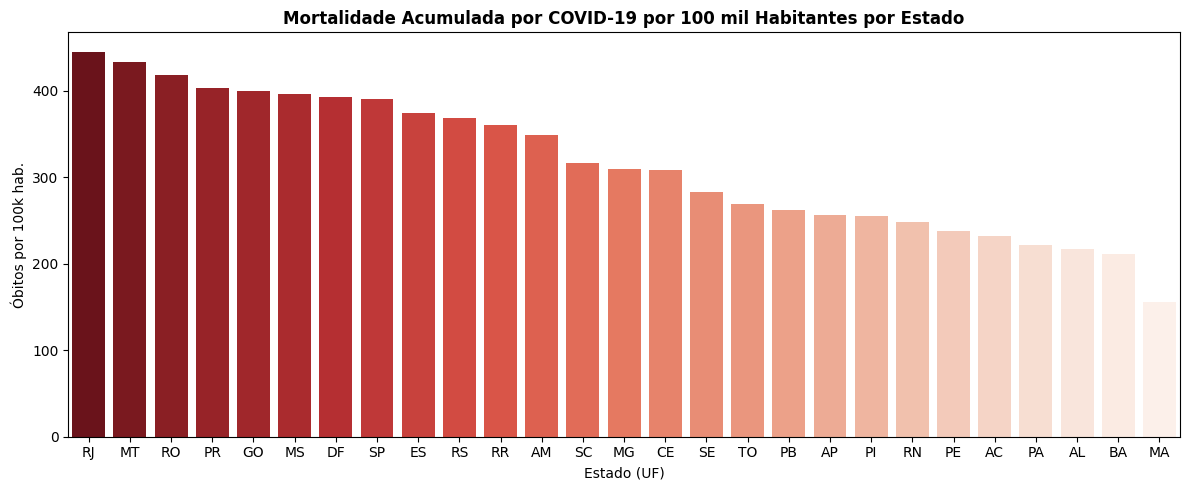

In [17]:
# ---------------------------------------------------------
# 1: Mortalidade por 100 mil habitantes por Estado (Gráfico de Barras)
# ---------------------------------------------------------

plt.figure(figsize=(12, 5))
df_sorted_obitos = df_ultimo.sort_values('deaths_per_100k_inhabitants', ascending=False)
sns.barplot(
    data=df_sorted_obitos,
    x='state',
    y='deaths_per_100k_inhabitants',
    palette='Reds_r'
)
plt.title('Mortalidade Acumulada por COVID-19 por 100 mil Habitantes por Estado', fontsize=12, fontweight='bold')
plt.xlabel('Estado (UF)')
plt.ylabel('Óbitos por 100k hab.')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

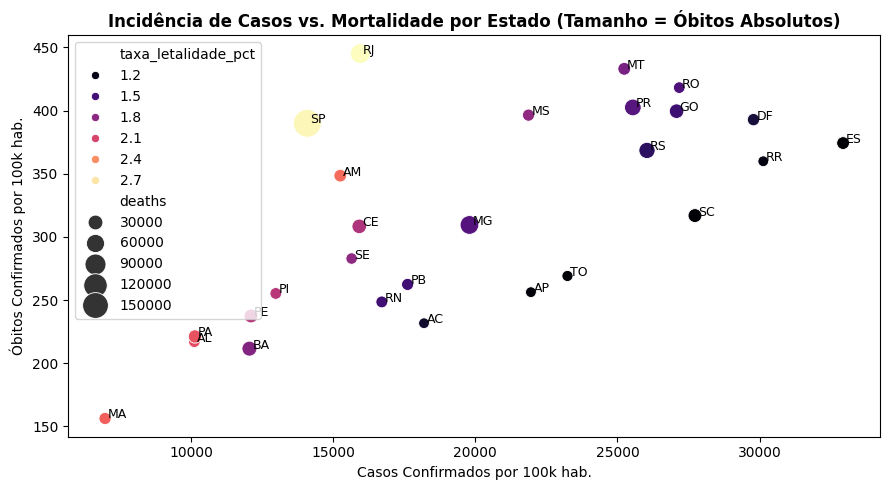

In [18]:
# ---------------------------------------------------------
# 2: Casos vs. Óbitos por 100k Habitantes (Scatter Plot)
# ---------------------------------------------------------

plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df_ultimo,
    x='totalCases_per_100k_inhabitants',
    y='deaths_per_100k_inhabitants',
    size='deaths',
    hue='taxa_letalidade_pct',
    palette='magma',
    sizes=(60, 400)
)
plt.title('Incidência de Casos vs. Mortalidade por Estado (Tamanho = Óbitos Absolutos)', fontsize=12, fontweight='bold')
plt.xlabel('Casos Confirmados por 100k hab.')
plt.ylabel('Óbitos Confirmados por 100k hab.')

for _, row in df_ultimo.iterrows():
    plt.text(row['totalCases_per_100k_inhabitants'] + 100, row['deaths_per_100k_inhabitants'], str(row['state']), fontsize=9)

plt.tight_layout()
plt.show()

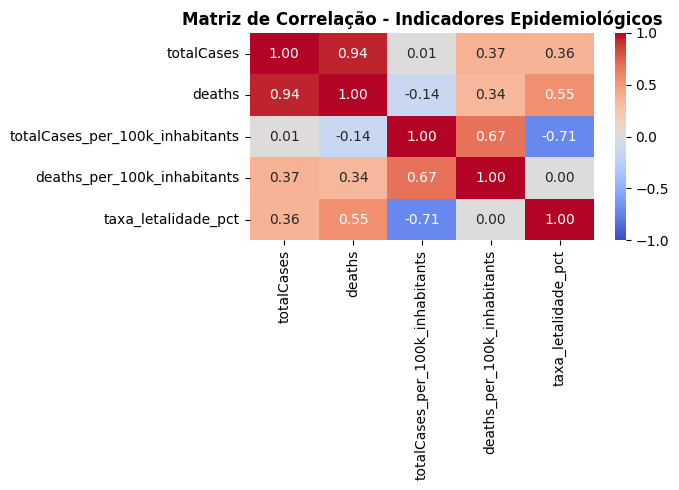

In [19]:
# ---------------------------------------------------------
# 3: Matriz de Correlação dos Indicadores Epidemiológicos (Heatmap)
# ---------------------------------------------------------

plt.figure(figsize=(7, 5))
cols_corr = ['totalCases', 'deaths', 'totalCases_per_100k_inhabitants', 'deaths_per_100k_inhabitants', 'taxa_letalidade_pct']
matriz_corr = df_ultimo[cols_corr].corr()

sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlação - Indicadores Epidemiológicos', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_492/211328901.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_letalidade, x='state', y='taxa_letalidade_pct', palette='Reds_r')


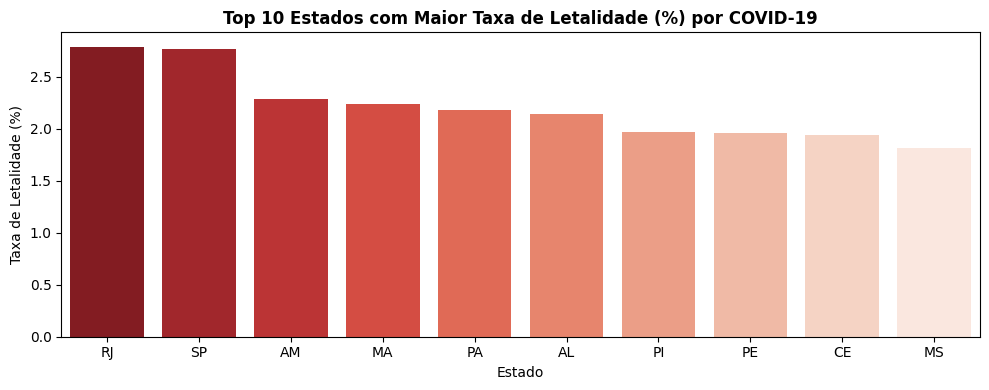

In [20]:
# ---------------------------------------------------------
# 4: Top 10 Estados com Maior Taxa de Letalidade (Gráfico de Barras)
# ---------------------------------------------------------

plt.figure(figsize=(10, 4))
top_letalidade = df_ultimo.sort_values('taxa_letalidade_pct', ascending=False).head(10)
sns.barplot(data=top_letalidade, x='state', y='taxa_letalidade_pct', palette='Reds_r')
plt.title('Top 10 Estados com Maior Taxa de Letalidade (%) por COVID-19', fontweight='bold')
plt.xlabel('Estado')
plt.ylabel('Taxa de Letalidade (%)')
plt.tight_layout()
plt.show()

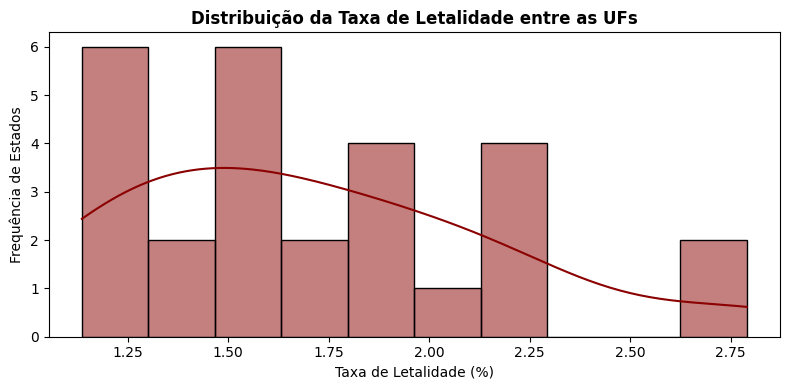

In [21]:
# ---------------------------------------------------------
# 5: Distribuição da Taxa de Letalidade (Histograma / KDE)
# ---------------------------------------------------------

plt.figure(figsize=(8, 4))
sns.histplot(df_ultimo['taxa_letalidade_pct'], kde=True, color='darkred', bins=10)
plt.title('Distribuição da Taxa de Letalidade entre as UFs', fontweight='bold')
plt.xlabel('Taxa de Letalidade (%)')
plt.ylabel('Frequência de Estados')
plt.tight_layout()
plt.show()